In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3

In [2]:
# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [2048, 2048, 1024]
box_length = [20000., 20000., 10000.]

boresight  = jnp.array([box_length[0]//2., box_length[1]//2.])
freqs      = jnp.logspace(1, 3, num=1000)
passband   = {'nu': jnp.array([150.]), 'g(nu)': jnp.array([1.])}
fwhm       = 10.

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 16, 0, 0, tzinfo=timezone.utc)

In [3]:
atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

In [4]:
# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

In [5]:
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)

1.1099999999999999 0.0607453701939497


In [6]:
ds = atmo_box.grid_wsp.grid_spacing[2] * jnp.ones((nside_grid[2],))

In [7]:
rho_w = atmo_box.atm_calibrator.q2rho_h2o*atmo_box.atm_calibrator.spec_humidity_profile

In [8]:
rho_w.shape

(1024,)

In [41]:
gamma_wet = []
gamma_dry = []

for j in range(nside_grid[2]):
    gamma_d, gamma_w = a3.compute_attenuation_point(atmo_box.atm_calibrator.temperature_profile[j], atmo_box.atm_calibrator.pressure[j]/100., rho_w[j], freqs)
    gamma_wet.append(gamma_w)
    gamma_dry.append(gamma_d)
    
gamma_wet = jnp.array(gamma_wet).T 
gamma_dry = jnp.array(gamma_dry).T

In [42]:
transmission_h2o = a3.attenuation_to_transmission(gamma_wet, ds/1e3)
transmission_o2  = a3.attenuation_to_transmission(gamma_dry,  ds/1e3)
transmission_tot = a3.attenuation_to_transmission(gamma_dry+gamma_wet,  ds/1e3)

Text(0.5, 1.0, 'Atmospheric transmission, Atacama, 2023-09-16 00:00:00+00:00')

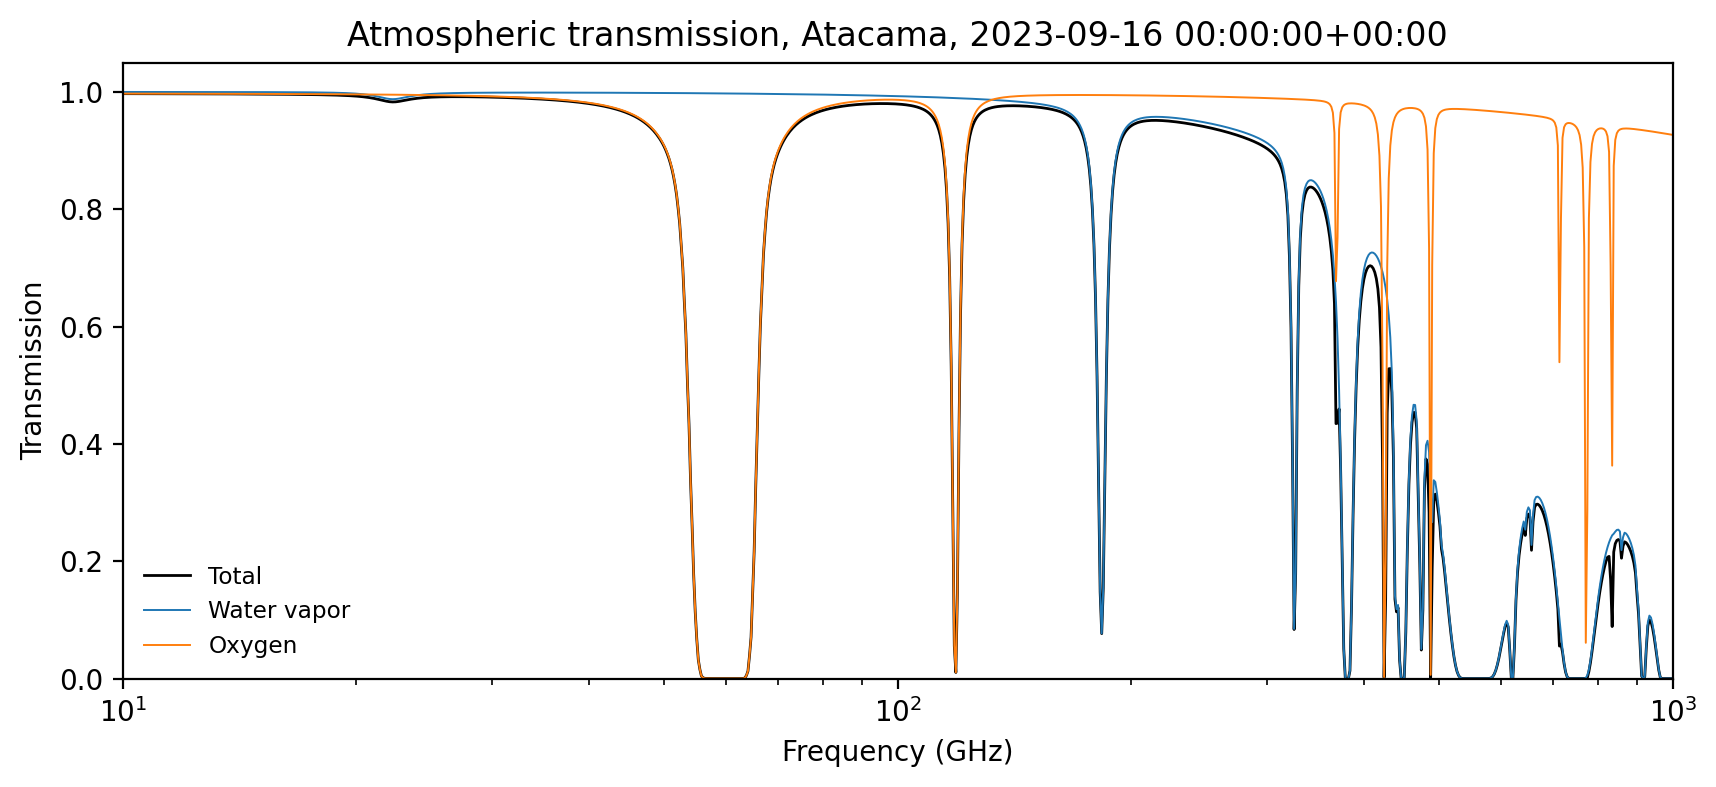

In [44]:
plt.figure(figsize=(10,4),dpi=200)
plt.semilogx(freqs, transmission_tot, 'k-', lw=1.0, label='Total')
plt.semilogx(freqs, transmission_h2o, '-', lw=0.7, label='Water vapor')
plt.semilogx(freqs, transmission_o2,  '-', lw=0.7, label='Oxygen')
plt.ylim(ymin=0., ymax=1.05)
plt.xlim(xmin=10, xmax=1000)
plt.legend(fontsize='small', frameon=False)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.title(f'Atmospheric transmission, Atacama, {time_utc}')